![Masthead AES](https://kyrill.ias.sdsmt.edu/wjc/eduresources/AES_Masthead.png)

# Plotting Fronts
This uses MetPy to decode text surface analysis bulletins from the Weather Prediction Center and then provides precipitation, mean sea level pressure, and lightning from other products.

![Surface Analysis Product](https://kyrill.ias.sdsmt.edu/Map_Wall/graphics_files/NWS_Sfc_Analysis.png)

The data sources are from the Unidata THREDDS Service, as follows:

* Fronts, Highs, Lows & Troughs: [NOAAPort KWBC Front Text Bulletin ASUS02 (Coded Surface Frontal Positions)](https://www.wpc.ncep.noaa.gov/html/read_coded_bull_hr.shtml). Typically Available ~1.5 hr from valid time.
* Mean Sea Level Reduced Pressure: [20-km Rapid Refresh Forecast/Analysis](https://rapidrefresh.noaa.gov/#:~:text=The%20Rapid%20Refresh%20is%20the,system%20to%20initialize%20that%20model.). F00 is available ~1.5-2.0 hr from valid time; otherwise, uses previous F01 forecast
* Rain/Snow/Ice/Freezing Rain: [20-km Rapid Refresh Forecast/Analysis](https://vlab.noaa.gov/web/mdl/nbm). F00 is available ~1 hr from valid time; otherwise, uses previous F01 forecast
* Lightening: [NOAA-NSSL Multi-Radar/Multi-Sensor System](https://www.nssl.noaa.gov/projects/mrms/).  Available 10-15 minutes from valid time.  Here we display the last 30-minutes of lightning strikes

## Libraries

In [97]:
import pandas as pd
import xarray as xr
import numpy as np
import datetime as dt
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import matplotlib        as mpl
import matplotlib.colors as mcolors
import cfgrib            as cfgrib
import cf_xarray         as cfgrib
import netCDF4           as nc



import timezonefinder    as tzf
import pytz              as pytz
import urllib    as urllib
import shutil
import metpy as metpy
import cartopy.crs       as ccrs
import cartopy.feature   as cfeature

import os                as     os
import pygrib            as pygrib

from statsmodels.distributions.empirical_distribution import ECDF

from datetime            import timezone

import metpy             as metpy

from metpy.cbook import get_test_data
from metpy.io import parse_wpc_surface_bulletin
from metpy.plots import ( scattertext, ColdFront, OccludedFront, StationaryFront,
                         StationPlot, WarmFront)


import siphon.catalog     as siphcat  
import siphon.ncss        as siphncss

from   siphon.cdmr        import Dataset
from   siphon.catalog     import TDSCatalog


import geopandas as gpd




working_dir = "./temp_sfc_analysis/"

os.system("rm -frv "+working_dir+"/*")

tz='America/Denver'


#
####################################################



## Malicious Compliance with SD Mines Communication Policy

In [98]:
####################################################
####################################################
#
# Mines Colors and Fonts
#

Mines_Blue = "#002554"



plt.rcParams.update({'text.color'      : Mines_Blue,
                     'axes.labelcolor' : Mines_Blue,
					 'axes.edgecolor'  : Mines_Blue,
					 'xtick.color'     : Mines_Blue,
					 'ytick.color'     : Mines_Blue})


#
####################################################
####################################################

---
## Clock Graphic

In [99]:
def plot_clock_stationary(fig,local_time):
    #####################################################
#

    axins = fig.add_axes(rect     =    [0,
                                        1-0.12, #0.015,
                                        0.12*8/9,
                                        0.12],
                          projection  =  "polar")
    
    time_for_clock = pd.to_datetime(local_time).time()
    
    hour   = time_for_clock.hour
    minute = time_for_clock.minute
    second = time_for_clock.second
    
    
    if ((hour >= 6) and (hour < 18)):
        Clock_Color = Mines_Blue
        Clock_BgndC = "white"           
    else:
        Clock_Color = "white"
        Clock_BgndC = Mines_Blue               
    
    
    circle_theta  = np.deg2rad(np.arange(0,360,0.01))
    circle_radius = circle_theta * 0 + 1
    
    if (hour > 12) :
        hour = hour - 12
    
    angles_h = 2*np.pi*hour/12+2*np.pi*minute/(12*60)+2*second/(12*60*60)
    angles_m = 2*np.pi*minute/60+2*np.pi*second/(60*60)
    

    
    
    plt.setp(axins.get_yticklabels(), visible=False)
    plt.setp(axins.get_xticklabels(), visible=False)
    axins.spines['polar'].set_visible(False)
    axins.set_ylim(0,1)
    axins.set_theta_zero_location('N')
    axins.set_theta_direction(-1)
    axins.set_facecolor(Clock_BgndC)
    axins.grid(False)
    
    axins.plot([angles_h,angles_h], [0,0.60], color=Clock_Color, linewidth=1.5, zorder=99999)
    axins.plot([angles_m,angles_m], [0,0.95], color=Clock_Color, linewidth=1.5, zorder=99999)
    axins.plot(circle_theta, circle_radius,  color=Mines_Blue, linewidth=1, zorder=99999)
#
##################################################

---
## Unidata Program for Plotting and Processing the Frontal Analysis Bulletin

In [110]:
def plot_bulletin(ax, data):
    """Plot a dataframe of surface features on a map."""
    # Set some default visual styling
    size = 9
    fontsize = 10
    HLfontsize = 30
    spacing = 2

    
    complete_style = { 'HIGH': {'color': 'blue', 'fontsize': HLfontsize},
                        'LOW': {'color': 'darkred', 'fontsize': HLfontsize},
                       'WARM': {'linewidth': 1, 'path_effects': [WarmFront(size=size, spacing=spacing)]},
                       'COLD': {'linewidth': 1, 'path_effects': [ColdFront(size=size, spacing=spacing)]},
                      'OCFNT': {'linewidth': 1, 'path_effects': [OccludedFront(size=size, spacing=spacing)]},
                      'STNRY': {'linewidth': 1, 'path_effects': [StationaryFront(size=size, spacing=spacing)]},
                       'TROF': {'linewidth': 2, 'linestyle': 'dashed',
                                'edgecolor': 'brown'}}

    complete_stylet = {'HIGH': {'color': 'blue', 'fontsize': fontsize},
                      'LOW': {'color': 'darkred', 'fontsize': fontsize},
                      'WARM': {'linewidth': 1, 'path_effects': [WarmFront(size=size, spacing=spacing)]},
                      'COLD': {'linewidth': 1, 'path_effects': [ColdFront(size=size, spacing=1)]},
                      'OCFNT': {'linewidth': 1, 'path_effects': [OccludedFront(size=size, spacing=1)]},
                      'STNRY': {'linewidth': 1, 'path_effects': [StationaryFront(size=size, spacing=1)]},
                      'TROF': {'linewidth': 2, 'linestyle': 'dashed',
                               'edgecolor': 'brown'}}



    if (1 == 1):
    
        print("=======================")
            
        print("Printing Highs and Lows")
        

        for field in ('HIGH', 'LOW'):
            rows = data[data["feature"] == field]
            x, y = zip(*((pt.x, pt.y) for pt in rows["geometry"]), strict=False)
            #scattertext(ax, x, y, field[0],
            #            **complete_style[field], transform=ccrs.PlateCarree(), clip_on=True)
            #scattertext(ax, x, y, rows["strength"], formatter='.0f', loc=(0, -10),
            #            **complete_stylet[field], transform=ccrs.PlateCarree(), clip_on=True)

    if (1  == 1):

        print("=======================")
            
        print("Printing Fronts")
     
        
        # Handle all the boundary types
        for field in ('WARM', 'COLD', 'STNRY', 'OCFNT', 'TROF'):
    
            
            rows = data[data["feature"] == field]
            ax.add_geometries(rows["geometry"], crs=ccrs.PlateCarree(), **complete_style[field],
                              facecolor='none')


---
## Read and pre-process Frontal Analysis Product

In [101]:
front_file_root   = "Fronts_highres_KWBC_"
fronts_collection = 'https://thredds.ucar.edu/thredds/catalog/noaaport/text/fronts/catalog.xml'

cat = TDSCatalog(fronts_collection)

result_loop = []
for item in cat.datasets:
    if front_file_root in item:
        result_loop.append(item)

most_recent_front_file = sorted(result_loop)[-1]
front_time_string      = most_recent_front_file[20:33]

url_fronts      = "https://thredds.ucar.edu/thredds/fileServer/noaaport/text/fronts/" + \
                   most_recent_front_file

temp_front_file = "./temp_sfc_analysis/fronts.txt"


print("downloading "+ url_fronts)
print("         to "+ temp_front_file)


urllib.request.urlretrieve(url_fronts, temp_front_file)

fronts_df = parse_wpc_surface_bulletin(temp_front_file)



time_fronts = fronts_df["valid"].iloc[0].replace(tzinfo=pytz.utc).to_pydatetime()


local_time  = time_fronts.astimezone(pytz.timezone(tz))

print("Time for Fronts: ",time_fronts, local_time)

fronts_df = gpd.GeoDataFrame(fronts_df, 
                             geometry='geometry', 
                             crs="EPSG:4326")

fronts_df


downloading https://thredds.ucar.edu/thredds/fileServer/noaaport/text/fronts/Fronts_highres_KWBC_20260816_2100.txt
         to ./temp_sfc_analysis/fronts.txt
Time for Fronts:  2026-08-16 21:00:00+00:00 2026-08-16 15:00:00-06:00


,valid,feature,strength,geometry
0,2026-08-16 21:00:00,HIGH,1026.0,POINT (-131.9 40.1)
1,2026-08-16 21:00:00,HIGH,1029.0,POINT (-140.2 47.7)
2,2026-08-16 21:00:00,HIGH,1020.0,POINT (-88.6 28.5)
3,2026-08-16 21:00:00,HIGH,1020.0,POINT (-78.3 26)
4,2026-08-16 21:00:00,HIGH,1020.0,POINT (-68.1 40.7)
...,...,...,...,...
99,2026-08-16 21:00:00,TROF,NaN,"LINESTRING (-161.6 59.7, -157.7 61.8, -152.8 6..."
100,2026-08-16 21:00:00,TROF,NaN,"LINESTRING (-93.9 45.3, -90 44, -86.3 44.4)"
101,2026-08-16 21:00:00,TROF,NaN,"LINESTRING (-92.3 46.6, -90.4 47.7, -88 48.5)"
102,2026-08-16 21:00:00,TROF,NaN,"LINESTRING (-87 37.6, -82.9 40.5, -81.7 43.9)"


In [102]:
type(fronts_df)

geopandas.geodataframe.GeoDataFrame

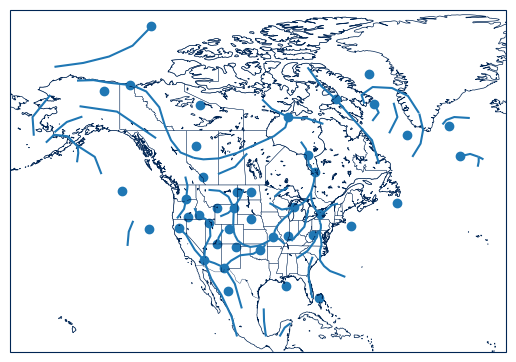

In [103]:
fig = plt.figure()
ax  = fig.add_subplot(1, 1, 1, 
                     projection=ccrs.PlateCarree())


fronts_df.plot(ax = ax)


###############################
#
# Geographic Features
# 

ax.add_feature(cfeature.COASTLINE.with_scale('50m'), 
               linewidth = 0.50, 
               edgecolor = Mines_Blue)

ax.add_feature(cfeature.STATES.with_scale('50m'),    
               linewidth = 0.25, 
               edgecolor = Mines_Blue)

ax.add_feature(cfeature.LAKES.with_scale('50m'),     
               linewidth = 0.50, 
               facecolor = "none", 
               edgecolor = Mines_Blue)
#
###############################



In [104]:
###############################
#
# Map Product Projection Information
#


class LowerAlbersEqualArea(ccrs.AlbersEqualArea):
    @property
    def threshold(self):
        return 1e3
        
myproj = ccrs.AlbersEqualArea(central_longitude  = -96.0, 
                              central_latitude   =  37.5, 
                              false_easting      =   0.0, 
                              false_northing     =   0.0, 
                              standard_parallels = (29.5, 45.5))

bbox = [-125,  -67,
          23,   53] 

bbox = [-125,  -67,
          23,   52] 

Lx = 14.152777777777779  
Ly =  9.88888888888889

#
###############################


###############################
#
# Time for Labels and Clock
#

valid_times = time_fronts.strftime("%Y-%m-%d %H%M %Z")
local_times = local_time.strftime("%Y-%m-%d %H%M %Z")
#hrrr_times  = time_hrrr_mslp.strftime("%Y-%m-%d %H%M %Z")
#nbm_times   = time_nbm_prec.strftime("%Y-%m-%d %H%M %Z")

#
###############################

In [109]:
###############################
#
# Drop Initial Plotting and Mapping
#

fig = plt.figure(figsize   = [Lx, Ly], 
                 facecolor = 'white')

ax = fig.add_subplot(1, 1, 1, 
                     projection=ccrs.PlateCarree())




ax.set_frame_on(False)
ax.set_extent(bbox, crs=ccrs.PlateCarree())

#
###############################



###############################
#
# Geographic Features
# 

ax.add_feature(cfeature.COASTLINE.with_scale('50m'), 
               linewidth = 0.50, 
               edgecolor = Mines_Blue)

ax.add_feature(cfeature.STATES.with_scale('50m'),    
               linewidth = 0.25, 
               edgecolor = Mines_Blue)

ax.add_feature(cfeature.LAKES.with_scale('50m'),     
               linewidth = 0.50, 
               facecolor = "none", 
               edgecolor = Mines_Blue)
#
###############################




###############################
#
# Fonts Fields
#

plot_bulletin(ax, fronts_df)

#
###############################

plt.show()



Printing Highs and Lows
Printing Fronts


ValueError: not enough values to unpack (expected 4, got 3)

<Figure size 1415.28x988.889 with 1 Axes>

In [10]:


###############################
#
# Drop Initial Plotting and Mapping
#

fig = plt.figure(figsize   = [Lx, Ly], 
                 facecolor = 'white')

ax = fig.add_subplot(1, 1, 1, 
                     projection=myproj)

plt.subplots_adjust(left   = 0.01, 
                    right  = 0.99, 
                    top    = 0.99, 
                    bottom = 0, 
                    wspace = 0)


ax.set_frame_on(False)
ax.set_extent(bbox, crs=ccrs.PlateCarree())

#
###############################


###############################
#
# Geographic Features
# 

ax.add_feature(cfeature.COASTLINE.with_scale('50m'), 
               linewidth = 0.50, 
               edgecolor = Mines_Blue)

ax.add_feature(cfeature.STATES.with_scale('50m'),    
               linewidth = 0.25, 
               edgecolor = Mines_Blue)

ax.add_feature(cfeature.LAKES.with_scale('50m'),     
               linewidth = 0.50, 
               facecolor = "none", 
               edgecolor = Mines_Blue)
#
###############################



###############################
#
# Fonts Fields
#

plot_bulletin(ax, fronts_df)

#
###############################

###############################
#
#  Labels and Annotations
#

plt.suptitle("NWS-WPC Surface Analysis",
             fontsize = 30, 
             color    = Mines_Blue)

plot_clock_stationary(fig, local_time)
ax.set_title(valid_times + "  (" + local_times+")",
             fontsize=20, 
             color=Mines_Blue)

##hrrr_label = "Rapid Refresh MSLP Using "+ hrrr_times+" Fx"+str(mslp_time).zfill(2)
#natbl_label = "National Blend PoPs Using "+ nbm_times+" Fx"+str(1).zfill(2)
#nldn_label = "30-min NLDN Strikes Using "+ valid_times +" Fx"+str(0).zfill(2)

xbot =  2983074
ybot = -1604583

#ax.text(xbot, ybot+100000,
#        hrrr_label, 
#        fontsize="x-small", 
#        horizontalalignment = "right")

#ax.text(xbot, ybot+50000,
#        natbl_label, 
#        fontsize="x-small", 
#        horizontalalignment = "right")

#ax.text(xbot, ybot,
#        nldn_label, 
#        fontsize="x-small", 
#        horizontalalignment = "right")

#
###############################


#########################################
#
# Save to File
#

#plt.savefig("./temp_sfc_analysis/NWS_Sfc_Analysis.png",
#                        facecolor   = 'white', 
#x                        transparent =   False)

print([ax.get_xbound(), ax.get_ybound()])
print([ax.get_xlim(), ax.get_ylim()])


plt.show()

#plt.close()
#os.system("mv -fv ./temp_sfc_analysis/NWS_Sfc_Analysis.png ./graphics_files/")

#
#########################################


Printing Highs and Lows
--- HIGH
     -- x: (-131.9, -140.2, -88.6, -78.3, -68.1, -53.6, -50.5, -62.5, -106.8, -99.6, -104.1, -117.0, -99.7, -104.3, -106.5, -110.5, -119.6, -114.8, -115.9, -146.0, -88.1, -80.2)
     -- y: (40.1, 47.7, 28.5, 26.0, 40.7, 45.4, 59.1, 71.5, 27.5, 47.6, 47.5, 57.0, 42.1, 36.3, 40.1, 44.4, 42.4, 50.6, 65.3, 68.0, 38.7, 38.8)
--- LOW
     -- x: (-92.7, -120.1, -87.9, -81.9, -79.5, -34.0, -37.4, -61.1, -72.9, -137.7, -131.3, -86.1, -114.6, -77.9, -96.8, -108.1, -122.3, -116.0, -112.8, -110.4, -105.2)
     -- y: (38.5, 46.2, 62.8, 55.1, 51.6, 54.9, 61.0, 65.5, 66.5, 69.4, 81.4, 44.5, 33.8, 43.1, 35.8, 32.2, 40.2, 42.8, 41.2, 36.9, 44.4)
Printing Fronts
--- WARM
--- COLD
--- STNRY
--- OCFNT
--- TROF
[(-2983074.2712756763, 2983074.271275605), (-1604583.3984679938, 1918749.413067444)]
[(-2983074.2712756763, 2983074.271275605), (-1604583.3984679938, 1918749.413067444)]


ValueError: not enough values to unpack (expected 4, got 3)

<Figure size 1415.28x988.889 with 2 Axes>

## Closeout

In [11]:
#########################################
#
# And we're done
#

print("And We're Done!")

#
#########################################

And We're Done!
